# **Netflix**!
What started in 1997 as a DVD rental service has since exploded into one of the largest entertainment and media companies.
Given the large number of movies and series available on the platform, it is a perfect opportunity to flex your exploratory data analysis skills and dive into the entertainment industry. <br>
You work for a production company that specializes in nostalgic styles. You want to do some research on movies released in the 1990's. You'll delve into Netflix data and perform exploratory data analysis to better understand this awesome movie decade! <br>
You have been supplied with the dataset `netflix_data.csv`, along with the following table detailing the column names and descriptions. Feel free to experiment further after submitting!

## The data
### **netflix_data.csv**
| Column | Description |
|--------|-------------|
| `show_id` | The ID of the show |
| `type` | Type of show |
| `title` | Title of the show |
| `director` | Director of the show |
| `cast` | Cast of the show |
| `country` | Country of origin |
| `date_added` | Date added to Netflix |
| `release_year` | Year of Netflix release |
| `duration` | Duration of the show in minutes |
| `description` | Description of the show |
| `genre` | Show genre |

In [3]:
# Importing pandas and matplotlib
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Read in the Netflix CSV as a DataFrame
netflix_df = pd.read_csv("netflix_data.csv")
netflix_df['release_year'].unique()

ModuleNotFoundError: No module named 'pandas'

## 1. Show in a histogram the frequencies of the movies during the 90s

In [ ]:
#Build a temporal dataframe for movies during 90s [1990 - 1999]
netflix_df_1990 = netflix_df[(netflix_df['release_year'] >= 1990) & (netflix_df['release_year'] <= 1999)]
netflix_df_1990['release_year'].unique()

plt.figure(figsize=(120,100))
plt.hist(x=netflix_df_1990['duration'],bins = 20)
plt.show()

## 2. What is the most common duration for movies during the 90s?

In [ ]:
#Find mode of duration for movies from 90s
netflix_df_1990['duration'].mode()
duration = int(94)

## 3. How many action movies from the 90s are short movies?
Short movies have a durations of less than 90min.

In [ ]:
#Show how genre is displayed as data
netflix_df['genre'].unique()

array(['Dramas', 'Horror Movies', 'Action', 'International TV',
       'Documentaries', 'Independent Movies', 'Comedies', 'Sci-Fi',
       'International Movies', 'Children', 'TV Shows', 'Uncategorized',
       'Classic Movies', 'Thrillers', 'Stand-Up', 'Anime Features',
       'Music', 'Anime Series', 'Kids', 'Docuseries', 'Crime TV',
       'British TV', 'Cult Movies', 'TV Action', 'Romantic TV',
       'TV Horror', 'Romantic Movies', 'TV Comedies', 'Classic',
       'Reality TV', 'LGBTQ Movies'], dtype=object)

In [ ]:
#Count how many movies are short (duration less than 90 minutes) from 90s
netflix_df_1990_short_action_movies = netflix_df_1990[
    (netflix_df_1990['duration'] <90) &
    (netflix_df_1990['genre'] == 'Action')]
short_movie_count = int(len(netflix_df_1990_short_action_movies))

# Additional exploration analysis (Self-Guided)
Here are some other questions that are interesting to discover from present dataset -> Python
1. How many movies were produced each year? <br>
   Show your anwer in a column chart (vertical)
2. What are the top 10 most recurring / casted actors for the period of 2005 to 2010? <br>
   Show your results in a dataframe. -> SQL
3. How many movies produced each country during the 90s? <br>
   Show your results in a bar chart (horizontal)
4. What was the most popular genre for each year in dataset? <br>
   Show the frequency and it's relative weight for that year genre frequency in a table.

Each question will have it's section to answer.

### 1. How many movies were produced each year?
Show results in a column chart (vertical)

In [ ]:
#Make a dataframe with counts of movies by year.
netflix_production = netflix_df.groupby('release_year').count()
netflix_production = netflix_production[['show_id']]

#Build column chart for yearly releases in Netflix.
list_values = netflix_production['show_id'].values.tolist()
max_value = max(list_values)
colors = ['red' if v==max_value else 'blue' for v in list_values]
production_mean = np.mean(list_values)
plt.figure(figsize=(18,10))
plt.bar(x=netflix_production.index,
        height=netflix_production['show_id'],
        color = colors)
plt.axhline(production_mean, color='gray', linestyle='--', label=f'Average: {production_mean:.2f}')
plt.show()

NameError: name 'netflix_df' is not defined

### 2. What are the top 10 most recurring / casted actors for the period of 2005 to 2010? 
Show your results in a query table -> SQL

In [ ]:
-- Extract movies from 2005 to 2010
SELECT *
FROM 'netflix_data.csv'
WHERE release_year >= 2005 AND release_year <= 2010

,show_id,type,title,director,cast,country,date_added,release_year,duration,description,genre
0,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,80,"In a postapocalyptic world, rag-doll robots hi...",Action
1,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,123,A brilliant group of students become card-coun...,Dramas
2,s10,Movie,1920,Vikram Bhatt,"Rajneesh Duggal, Adah Sharma, Indraneil Sengup...",India,"December 15, 2017",2008,143,An architect and his wife move into a castle t...,Horror Movies
3,s43,Movie,Çok Filim Hareketler Bunlar,Ozan Açıktan,"Ayça Erturan, Aydan Taş, Ayşegül Akdemir, Burc...",Turkey,"March 10, 2017",2010,99,Vignettes of the summer holidays follow vacati...,Comedies
4,s45,Movie,Æon Flux,Karyn Kusama,"Charlize Theron, Marton Csokas, Jonny Lee Mill...",United States,"February 1, 2018",2005,93,"Aiming to hasten an uprising, the leader of an...",Action
...,...,...,...,...,...,...,...,...,...,...,...
523,s7764,Movie,Zenda,Avadhoot Gupte,"Santosh Juvekar, Siddharth Chandekar, Sachit P...",India,"February 15, 2018",2009,120,A change in the leadership of a political part...,Dramas
524,s7775,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,158,"A political cartoonist, a crime reporter and a...",Cult Movies
525,s7779,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,88,Looking to survive in a world taken over by zo...,Comedies
526,s7782,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,88,"Dragged from civilian life, a former superhero...",Children


As cast data is a group of cast, no individual actor can be extracted from data using SQL. <br>
Python will be used to generate list of individual actors and make the count according to original table from SQL

In [ ]:
#Extract all actors from 'cast' in movies from 2005 to 2010
netflix_actors['cast'].tolist()
all_actors = []
delimiter = ","
all_actors = [ cast_group.split(delimiter) for cast_group in netflix_actors['cast'].tolist()]
trimmed_actors = []
all_cast = []
for cast_group in all_actors:
    trimmed_actors = [actor.strip() for actor in cast_group]
    for actor in trimmed_actors:
        all_cast.append(actor)
#All_cast has a length of 4873 actors (repeated)

unique_all_cast = list(dict.fromkeys(all_cast))
#unique_all_cast has a length of 3599 actors. Hopefully, non-repeated

#Make a Dataframe will all unique actors
all_actors_df = pd.DataFrame(data = unique_all_cast)
all_actors_df.columns = ['Actor']  #Rename column to 'Actor'

#Count the ocurrences of actor inside 'cast' in original dataframe
def count_ocurrences(row_df2,df1_column):
    search_string = row_df2['Actor']
    count_series = df1_column.str.count(search_string)
    total_count = count_series.sum()
    return total_count

all_actors_df['Movie_count'] = all_actors_df.apply(
    lambda row:count_ocurrences(row,netflix_actors['cast']),
    axis = 1
)

Now we can generate SQL based of previously built dataframe in Python

In [ ]:
SELECT *
FROM all_actors_df
ORDER BY Movie_count DESC
LIMIT 10

,Actor,Movie_count
0,Rajpal Yadav,12
1,Paresh Rawal,12
2,Anupam Kher,11
3,Akshay Kumar,11
4,Kareena Kapoor,9
5,Boman Irani,9
6,Om Puri,9
7,Ahmed Helmy,9
8,Shreyas Talpade,8
9,Katrina Kaif,8


## 3. How many movies produced each country during the 90s? <br>
Show your results in a bar chart (horizontal)

In [ ]:
SELECT country, COUNT(show_id)
FROM netflix_df
WHERE release_year >= 1990 AND release_year <= 1999
GROUP BY country
ORDER BY count(show_id) DESC

,country,count(show_id)
0,United States,100
1,India,34
2,United Kingdom,17
3,Hong Kong,11
4,Australia,5
5,France,5
6,Mexico,3
7,Germany,2
8,Japan,2
9,Poland,1


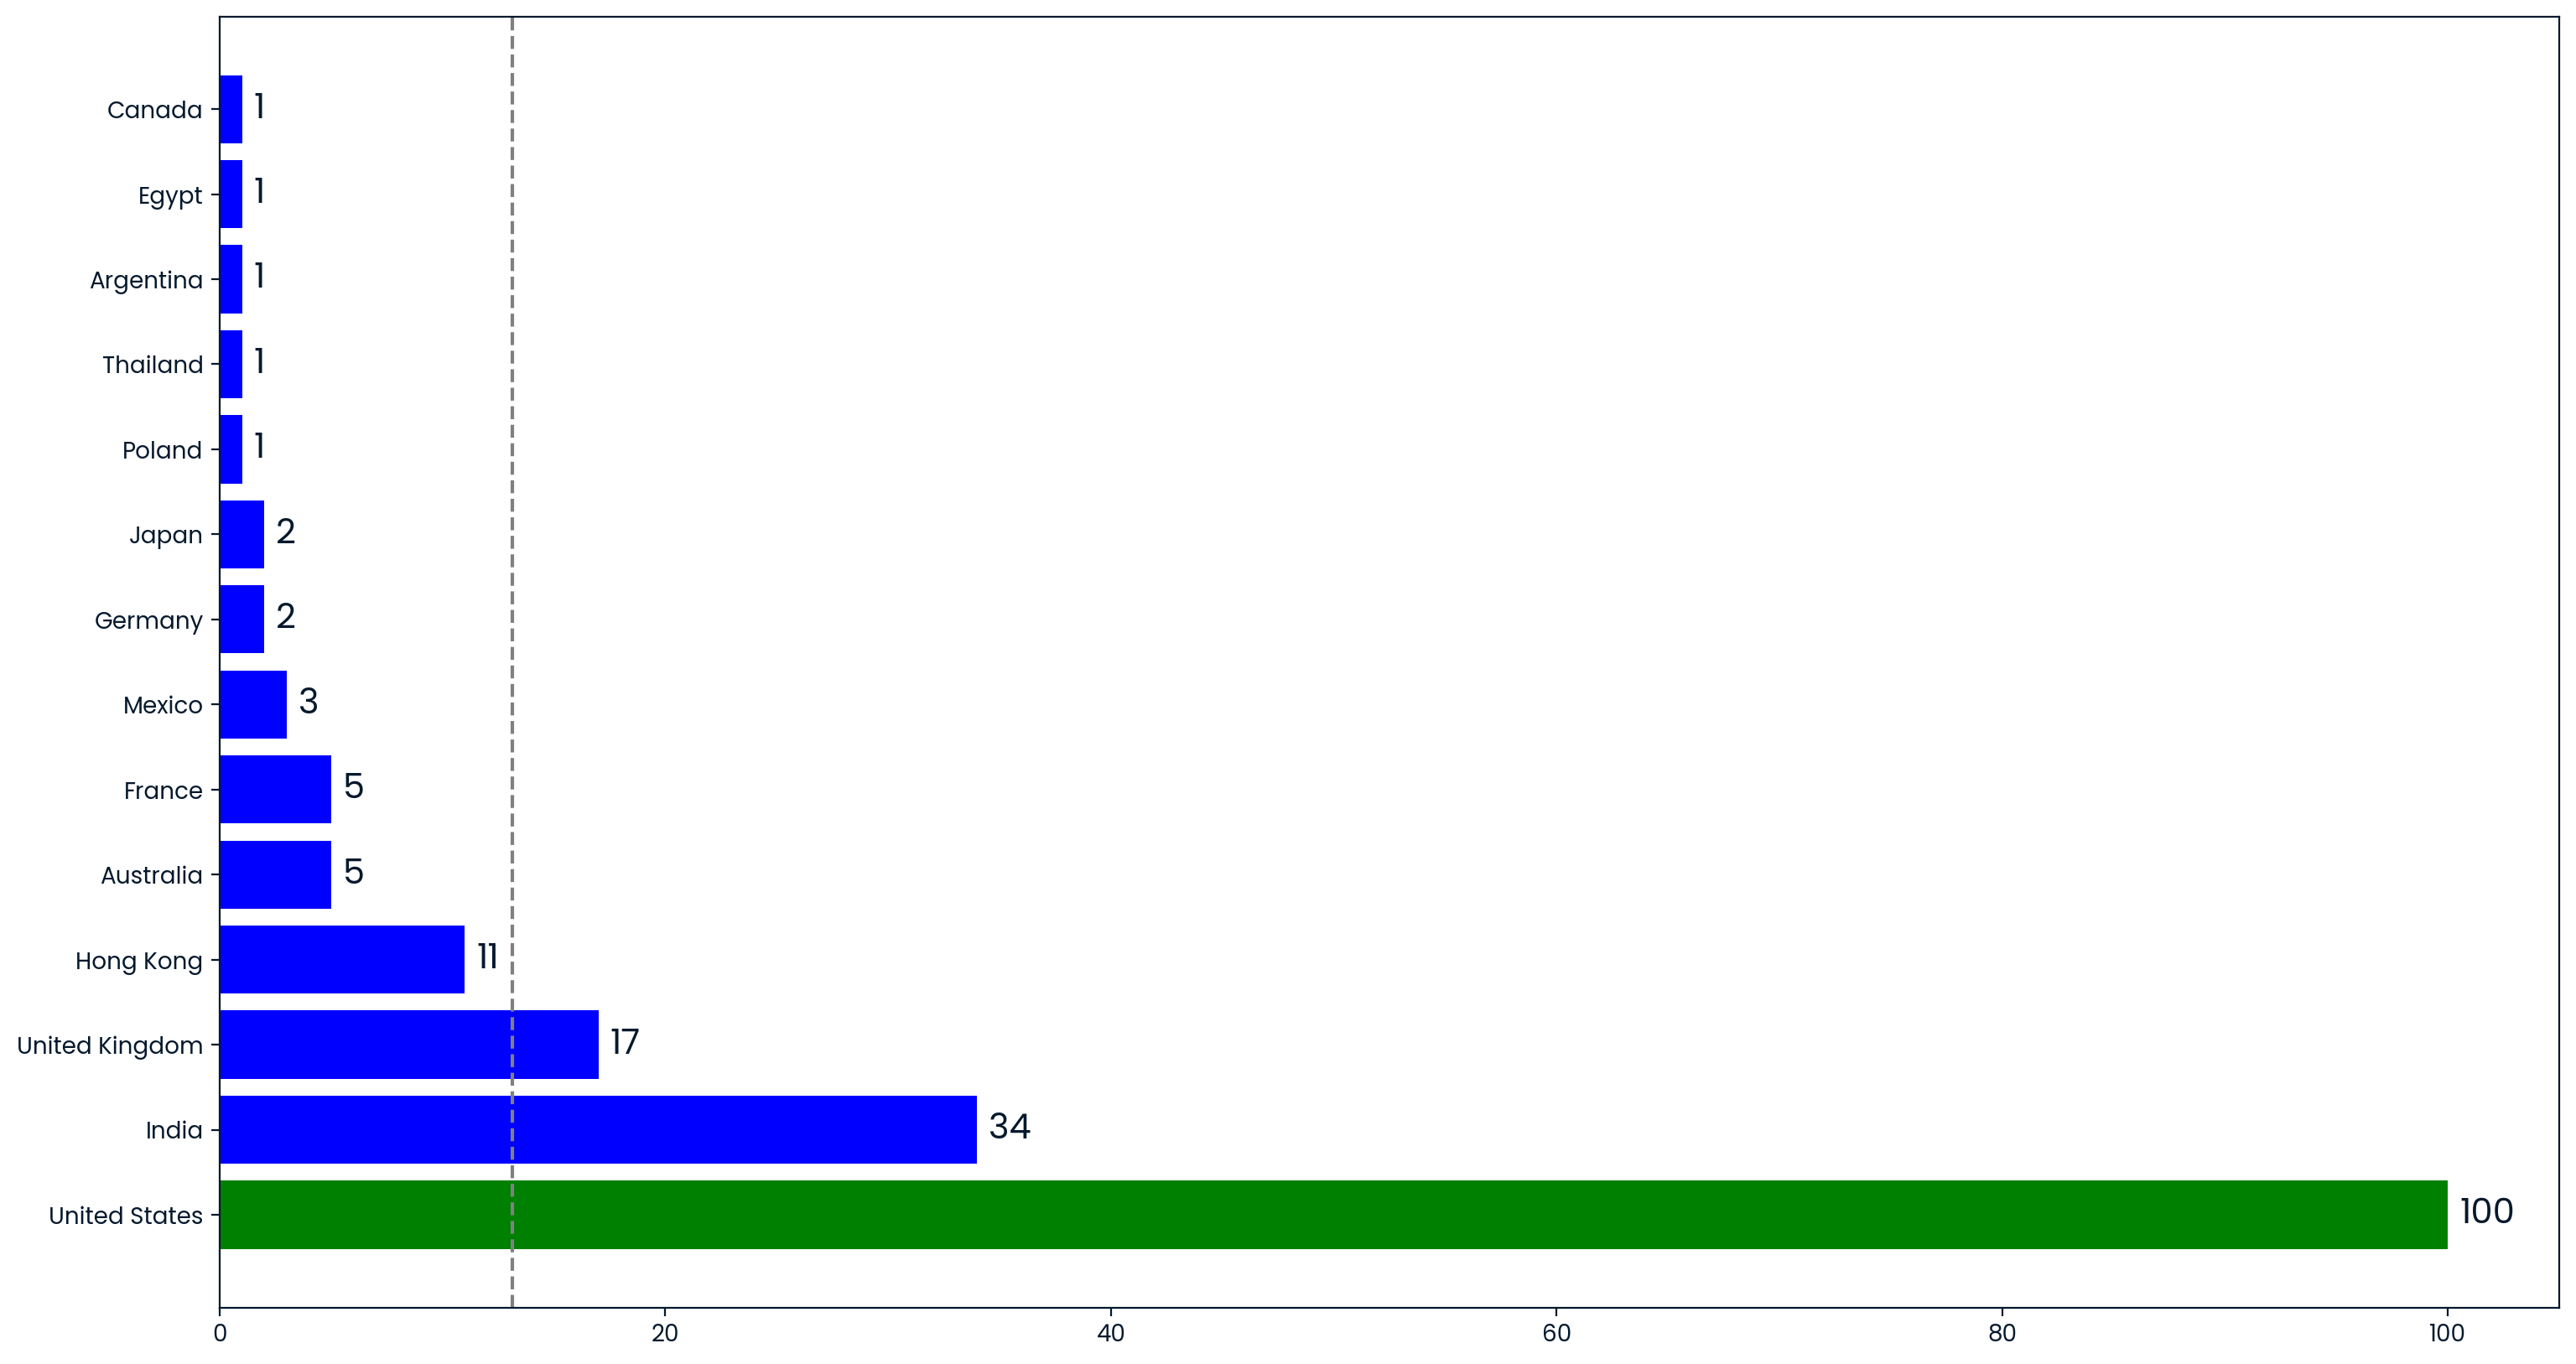

In [ ]:
#Build bar chart for yearly releases in Netflix.
list_values2 = netflix_country_90['count(show_id)'].values.tolist()
max_value2 = max(list_values2)
colors2 = ['green' if v==max_value2 else 'blue' for v in list_values2]
production_mean2 = np.mean(list_values2)

plt.figure(figsize=(18,10))
plt.barh(netflix_country_90['country'],
        width=netflix_country_90['count(show_id)'],
        color = colors2)
bars = plt.barh(netflix_country_90['country'],
        width=netflix_country_90['count(show_id)'],
        color = colors2)
plt.bar_label(bars,
             label_type='edge',
             padding=5,
             fontsize=15)
plt.axvline(production_mean2, color='gray', linestyle='--', label=f'Average: {production_mean:.2f}')
plt.show()

## 4. What was the most popular genre for each year in dataset? <br>
Show the frequency and it's relative weight for that year genre frequency in a table.

In [ ]:
SELECT release_year, genre, count(show_id) AS qty
FROM netflix_df
GROUP BY release_year, genre
ORDER BY release_year DESC, genre DESC

SyntaxError: invalid syntax (1663836253.py, line 1)

In [ ]:
netflix_popular_topgenres = netflix_popular_genres.groupby(['release_year','genre']).max().sort_values(by=['qty'],ascending=False).reset_index()
netflix_popular_topgenres.drop_duplicates(subset=['release_year'], inplace=True)
netflix_popular_topgenres.sort_values(by='release_year', ascending=False)

,release_year,genre,qty
280,2021,Anime Series,1
9,2020,Dramas,87
3,2019,Dramas,142
0,2018,Dramas,187
1,2017,Dramas,186
...,...,...,...
360,1947,Classic Movies,1
361,1946,Classic Movies,1
362,1945,Classic Movies,1
392,1944,Classic Movies,1
